In [2]:
%run api.ipynb

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns





<class 'pandas.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 15 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   date                                                  1776 non-null   datetime64[us]
 1   subways_total_estimated_ridership                     1776 non-null   int64         
 2   subways_of_comparable_pre_pandemic_day                1776 non-null   float64       
 3   buses_total_estimated_ridersip                        1776 non-null   int64         
 4   buses_of_comparable_pre_pandemic_day                  1776 non-null   float64       
 5   lirr_total_estimated_ridership                        1776 non-null   int64         
 6   lirr_of_comparable_pre_pandemic_day                   1776 non-null   float64       
 7   metro_north_total_estimated_ridership                 1776 non-null   int64         
 8  

In [3]:
df.head()
df.tail()

,date,subways_total_estimated_ridership,subways_of_comparable_pre_pandemic_day,buses_total_estimated_ridersip,buses_of_comparable_pre_pandemic_day,lirr_total_estimated_ridership,lirr_of_comparable_pre_pandemic_day,metro_north_total_estimated_ridership,metro_north_of_comparable_pre_pandemic_day,access_a_ride_total_scheduled_trips,access_a_ride_of_comparable_pre_pandemic_day,bridges_and_tunnels_total_traffic,bridges_and_tunnels_of_comparable_pre_pandemic_day,staten_island_railway_total_estimated_ridership,staten_island_railway_of_comparable_pre_pandemic_day
1771,2025-01-05,1791020,0.86,618750,0.67,96683,1.17,79761,0.88,23665,1.75,726411,1.06,2039,0.74
1772,2025-01-06,3436491,0.67,1238969,0.61,229503,0.76,202575,0.75,35840,1.27,792617,0.91,6887,0.42
1773,2025-01-07,3781536,0.74,1275936,0.62,245930,0.81,220945,0.82,38048,1.34,842968,0.97,7409,0.45
1774,2025-01-08,3830616,0.74,1256260,0.61,239444,0.79,209550,0.78,39406,1.39,852748,0.98,7798,0.48
1775,2025-01-09,3734383,0.73,787710,0.38,229804,0.76,198894,0.74,38431,1.36,869256,1.00,6841,0.42


In [4]:

df_by_year_2020 = df[(df['date'].dt.year == 2020)]
print(df_by_year_2020.head())

        date  subways_total_estimated_ridership  \
0 2020-03-01                            2212965   
1 2020-03-02                            5329915   
2 2020-03-03                            5481103   
3 2020-03-04                            5498809   
4 2020-03-05                            5496453   

   subways_of_comparable_pre_pandemic_day  buses_total_estimated_ridersip  \
0                                    0.97                          984908   
1                                    0.96                         2209066   
2                                    0.98                         2228608   
3                                    0.99                         2177165   
4                                    0.99                         2244515   

   buses_of_comparable_pre_pandemic_day  lirr_total_estimated_ridership  \
0                                  0.99                           86790   
1                                  0.99                          321569   
2    

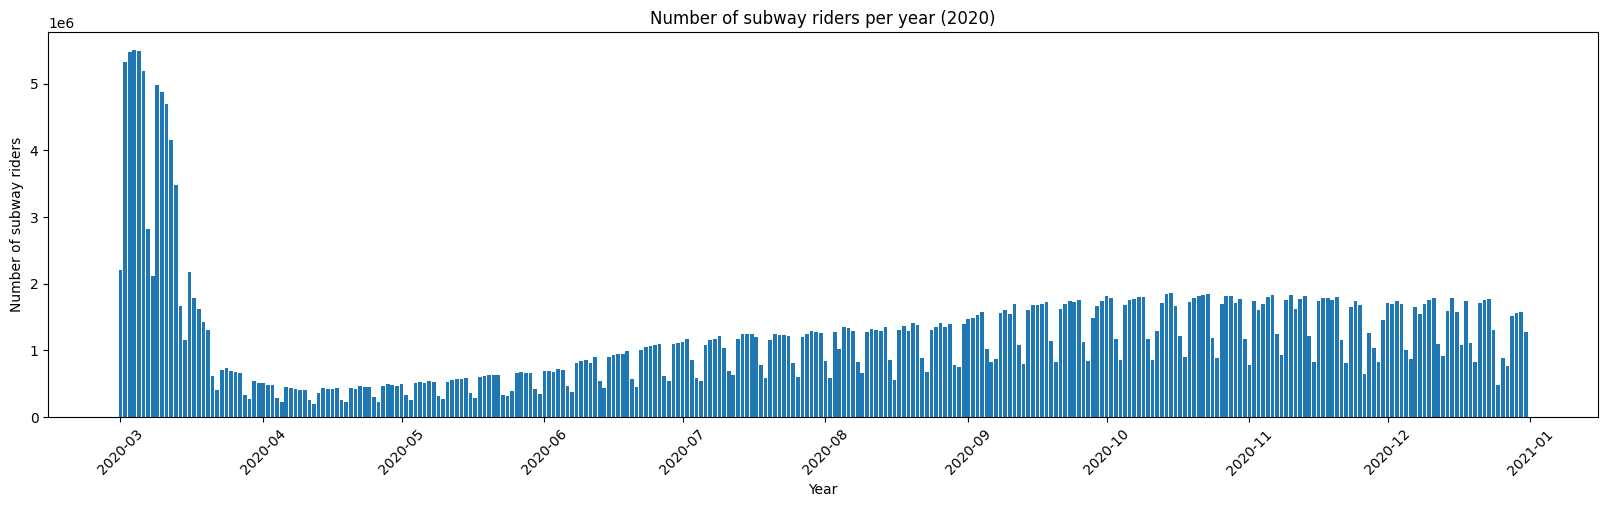

In [8]:

plt.figure(figsize = (20, 5)) # Increase output size.
plt.bar(x = df_by_year_2020['date'], height = df_by_year_2020['subways_total_estimated_ridership'])
plt.plot()
plt.xlabel("Year")
plt.ylabel("Number of subway riders")
plt.title("Number of subway riders per year (2020)")
plt.xticks(rotation = 45, fontsize = 10) # Rotate x-axis labels and decrease font size.
plt.show()

In [ ]:
# Group 2020-2025 data by year and sum.
# Create four new columns.
df['year'] = df['date'].dt.strftime('%Y')
df_by_year = df.groupby('year')['subways_total_estimated_ridership'].sum().reset_index()
print(df_by_year.head())


   year  subways_total_estimated_ridership
0  2020                          370096769
1  2021                          759810246
2  2022                         1012505879
3  2023                         1150217108
4  2024                         1194201712


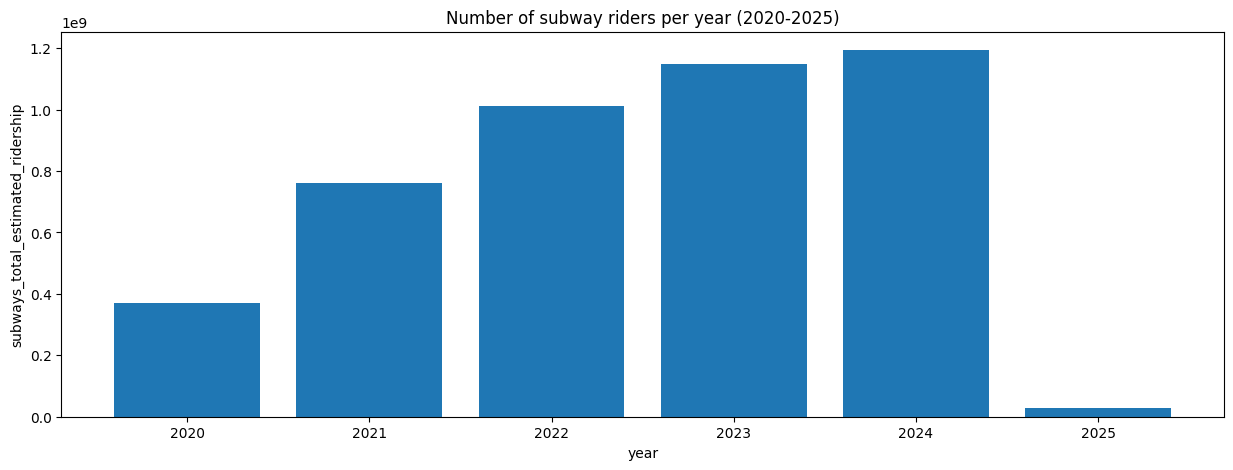

In [15]:
plt.figure(figsize = (15, 5))
plt.bar(x = df_by_year['year'], height = df_by_year['subways_total_estimated_ridership'])
plt.plot()
plt.xlabel('year')
plt.ylabel('subways_total_estimated_ridership')
plt.title('Number of subway riders per year (2020-2025)')
plt.show()

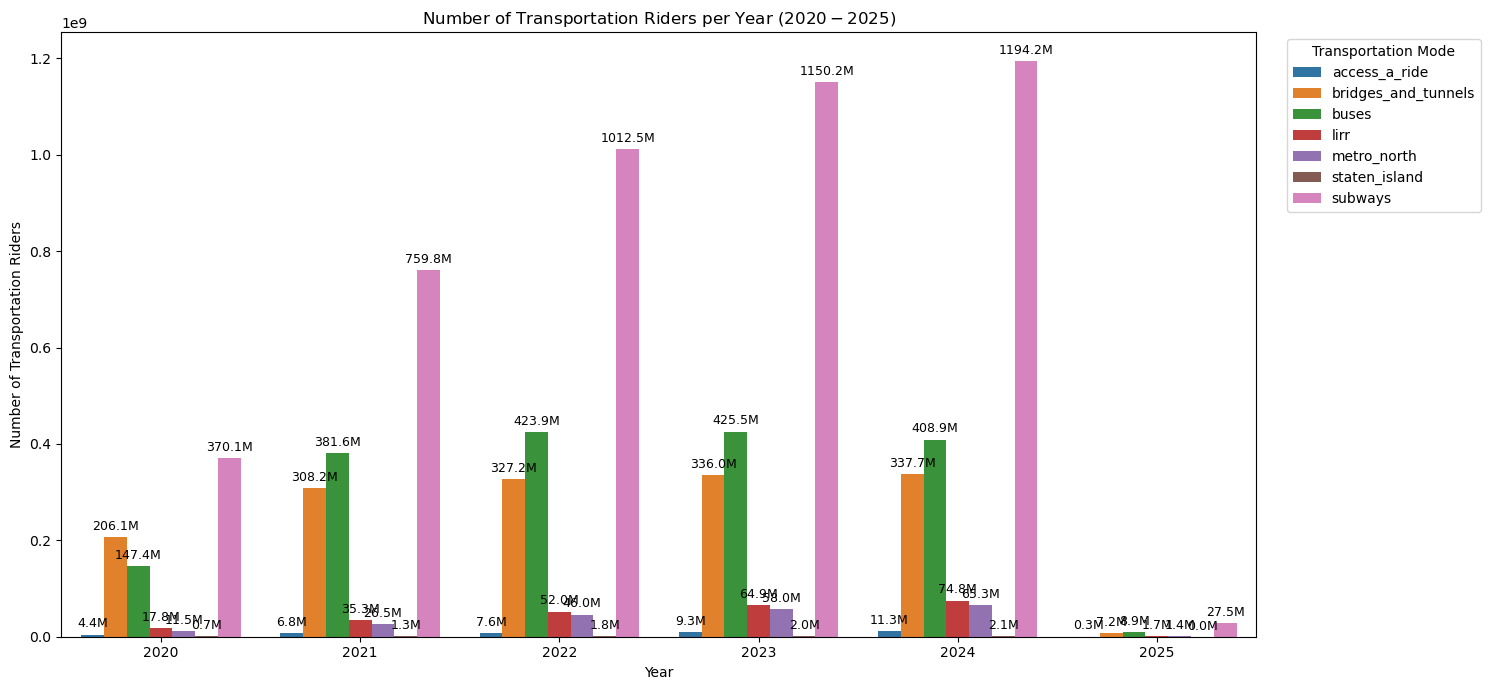

In [30]:
# 1. Map columns and extract the year string
df['access_a_ride'] = df['access_a_ride_total_scheduled_trips']
df['bridges_and_tunnels'] = df['bridges_and_tunnels_total_traffic']
df['buses'] = df['buses_total_estimated_ridersip']
df['lirr'] = df['lirr_total_estimated_ridership']
df['metro_north'] = df['metro_north_total_estimated_ridership']
df['staten_island'] = df['staten_island_railway_total_estimated_ridership']
df['subways'] = df['subways_total_estimated_ridership']
df['year'] = df['date'].dt.strftime('%Y')

# Define list of target transportation columns
modes = ['access_a_ride', 'bridges_and_tunnels', 'buses', 'lirr', 'metro_north', 'staten_island', 'subways']

# 2. Subset the data including the 'year' column
ridership_wide = df[['year'] + modes]

# 3. Aggregate data by year (summing rows to get total annual ridership)
ridership_annual = ridership_wide.groupby('year').sum().reset_index()

# 4. Melt the dataframe from wide format to long format
ridership_long = pd.melt(
    ridership_annual, 
    id_vars=['year'], 
    value_vars=modes, 
    var_name='transportation_mode', 
    value_name='ridership'
)

# 5. Initialize the plot
fig, ax = plt.subplots(figsize=(15, 7))

p = sns.barplot(
    data=ridership_long,
    x='year',
    y='ridership',
    hue='transportation_mode',
    ax=ax
)

# 6. Add clean value annotations on top of the bars
# Modern matplotlib version avoids ordering bugs caused by looping over p.patches
for container in p.containers:
    # Convert raw values into millions (e.g., 12.3M)
    labels = [f'{val / 1e6:.1f}M' if val > 0 else '' for val in container.datavalues]
    p.bar_label(container, labels=labels, padding=3, fontsize=9, rotation=0)

# Customizing labels, title, and legend placement
plt.xlabel("Year")
plt.ylabel("Number of Transportation Riders")
plt.title("Number of Transportation Riders per Year ($2020-2025$)")

# Place legend outside of the plot space so it doesn't overlap the bars
plt.legend(title="Transportation Mode", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()